In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


The dataset used in this project contains customer information related to their purchasing behavior and engagement with the business. The main objective is to predict whether a customer is likely to churn.
The dataset consists of the following features:
- Age: The age of the customer.
- Annual_Income: The yearly income of the customer.
- Purchase_Frequency: The number of purchases made by the customer over a given period.
- Membership_Level: The membership category of the customer (e.g., Basic, Silver, Gold, Premium).
- Spending_Score: A score representing the customer's spending behavior, typically on a scale from 1 to 10.
- Churn_Status: The target variable indicating whether the customer has churned (1) or not (0).

The dataset may initially contain missing values and duplicate records, which were handled during preprocessing. Additionally, the class distribution was imbalanced, meaning the number of churned and non-churned customers was unequal.

To address this imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied to create a balanced training dataset, ensuring that the models learn patterns effectively without bias toward the majority class.

(2000, 9)
Churn_Status
0    0.6675
1    0.3325
Name: proportion, dtype: float64
Shape: (2000, 9)


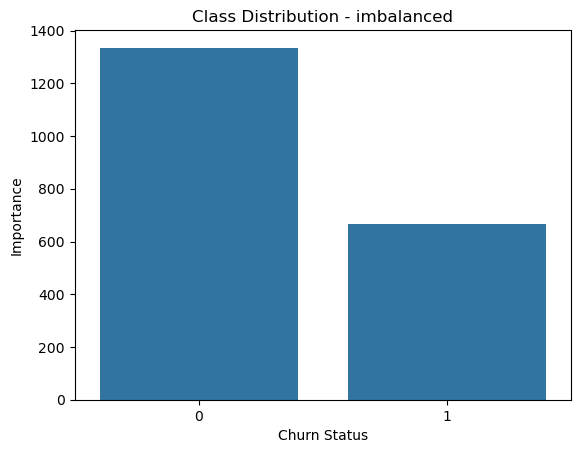

CustomerID            0
Name                  0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Membership_Level      0
Purchase_Frequency    0
Churn_Status          0
dtype: int64
Selected features: ['Age', 'Annual_Income', 'Purchase_Frequency', 'Membership_Level', 'Spending_Score']
Features ready: (2136, 5)
Perfect balance: [1068 1068]


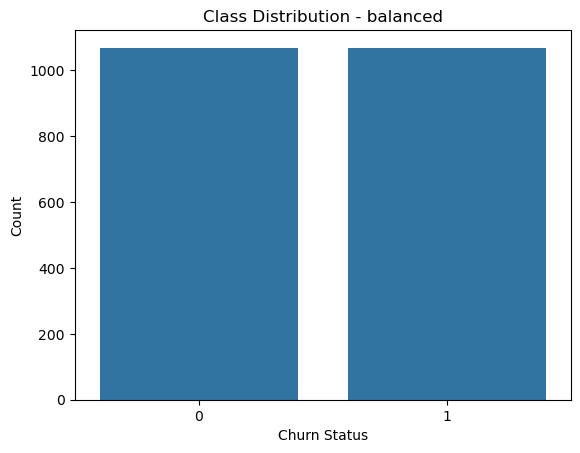

In [8]:
df = pd.read_csv(r"C:\Users\SAHANA\Downloads\customer_data_with_churn.csv")
print(df.shape)
#print(df.info())
print(df['Churn_Status'].value_counts(normalize=True))
print("Shape:", df.shape)

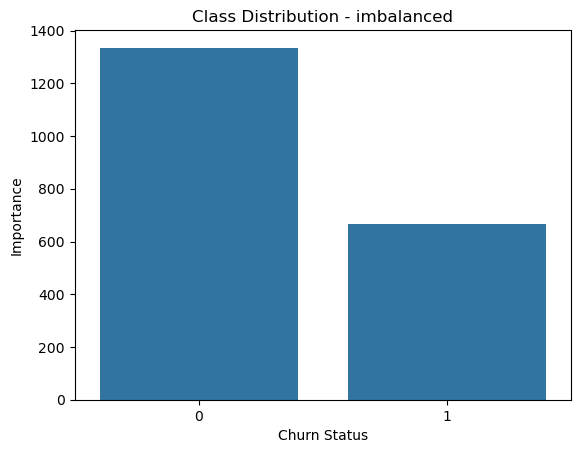

In [18]:
sns.countplot(x='Churn_Status', data=df)
plt.title("Class Distribution - imbalanced")
plt.xlabel("Churn Status")
plt.ylabel("Importance")
plt.show()

In [19]:
print(df.isnull().sum())

# these handles missing values , but in this code its not req
df = df.dropna() 
df.drop_duplicates(inplace=True)
features = ['Age','Annual_Income','Purchase_Frequency','Membership_Level','Spending_Score']
x = df[features].copy()
print("Selected features:", x.columns.tolist())
y = df['Churn_Status']
le = LabelEncoder()
x['Membership_Level'] = le.fit_transform(x['Membership_Level'])  # classes - 0,1,2,3

CustomerID            0
Name                  0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Membership_Level      0
Purchase_Frequency    0
Churn_Status          0
dtype: int64
Selected features: ['Age', 'Annual_Income', 'Purchase_Frequency', 'Membership_Level', 'Spending_Score']


In [20]:
x_train,x_test,y_train,y_test = train_test_split(x, y,test_size=0.2, random_state=42, stratify=y)

#To balance class of the dataset to avoid unnecessary bias
smote = SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)
print("Features ready:", x_train_bal.shape)
print("Perfect balance:", np.bincount(y_train_bal))

Features ready: (2136, 5)
Perfect balance: [1068 1068]


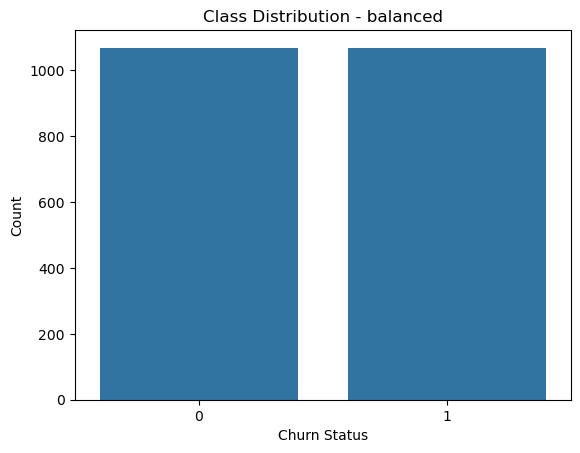

In [21]:
#this plot shows that the dataset is fully balanced after applying SMOTE.
sns.countplot(x=y_train_bal)
plt.title("Class Distribution - balanced")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

In [23]:
#model training and evaluation
def lightgbm(x_train_bal, y_train_bal, x_test, y_test):
    lgb = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    lgb.fit(x_train_bal, y_train_bal)
    lgb_pred = lgb.predict(x_test)
    lgb_proba = lgb.predict_proba(x_test)[:,1] 
    lgb_auc = roc_auc_score(y_test, lgb_proba) 
    threshold = 0.3
    lgb_pred = (lgb_proba > threshold).astype(int)
    print(f"LightGBM AUC: {lgb_auc:.3f}")
    print(classification_report(y_test, lgb_pred)) 
    print("Accuracy:", round(accuracy_score(y_test, lgb_pred), 3))
    print("Precision:", round(precision_score(y_test, lgb_pred), 3))
    print("Recall:", round(recall_score(y_test, lgb_pred), 3))
    print("F1 Score:", round(f1_score(y_test, lgb_pred), 3))
    return lgb_auc, lgb_pred, lgb 




In [24]:
def xgboost(x_train_bal, y_train_bal, x_test, y_test):
    xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb.fit(x_train_bal, y_train_bal)
    xgb_pred = xgb.predict(x_test)
    xgb_proba = xgb.predict_proba(x_test)[:,1]  
    xgb_auc = roc_auc_score(y_test, xgb_proba)
    print(f"XGBoost AUC: {xgb_auc:.3f}")
    print(classification_report(y_test, xgb_pred)) 
    print("Accuracy:", round(accuracy_score(y_test, xgb_pred), 3))
    print("Precision:", round(precision_score(y_test, xgb_pred), 3))
    print("Recall:", round(recall_score(y_test, xgb_pred), 3))
    print("F1 Score:", round(f1_score(y_test, xgb_pred), 3))
    return xgb_auc, xgb_pred, xgb 



In [25]:
def random_forest(x_train_bal, y_train_bal, x_test, y_test):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(x_train_bal, y_train_bal)
    rf_pred = rf.predict(x_test) 
    rf_proba = rf.predict_proba(x_test)[:,1]  
    rf_auc = roc_auc_score(y_test, rf_proba)  
    print(f"Random Forest AUC: {rf_auc:.3f}")
    print(classification_report(y_test, rf_pred)) 
    print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
    print("Precision:", round(precision_score(y_test, rf_pred), 3))
    print("Recall:", round(recall_score(y_test, rf_pred), 3))
    print("F1 Score:", round(f1_score(y_test, rf_pred), 3))
    return rf_auc, rf_pred, rf    


In [26]:
def decision_tree(x_train_bal, y_train_bal, x_test, y_test):
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(x_train_bal, y_train_bal)
    dt_pred = dt.predict(x_test)
    dt_proba = dt.predict_proba(x_test)[:,1]
    dt_auc = roc_auc_score(y_test, dt_proba)
    print(f"Decision Tree AUC: {dt_auc:.3f}")
    print(classification_report(y_test, dt_pred))
    print("Accuracy:", round(accuracy_score(y_test, dt_pred), 3))
    print("Precision:", round(precision_score(y_test, dt_pred), 3))
    print("Recall:", round(recall_score(y_test, dt_pred), 3))
    print("F1 Score:", round(f1_score(y_test, dt_pred), 3))
    return dt_auc, dt_pred, dt 



In [27]:
lgb_auc, lgb_pred, lgb_model = lightgbm(x_train_bal, y_train_bal, x_test, y_test)
xgb_auc, xgb_pred, xgb_model = xgboost(x_train_bal, y_train_bal, x_test, y_test)
rf_auc, rf_pred, rf_model = random_forest(x_train_bal, y_train_bal, x_test, y_test)
dt_auc, dt_pred, dt_model = decision_tree(x_train_bal, y_train_bal, x_test, y_test)

LightGBM AUC: 0.710
              precision    recall  f1-score   support

           0       0.78      0.52      0.62       267
           1       0.42      0.71      0.53       133

    accuracy                           0.58       400
   macro avg       0.60      0.61      0.57       400
weighted avg       0.66      0.58      0.59       400

Accuracy: 0.58
Precision: 0.422
Recall: 0.707
F1 Score: 0.528


C:\Users\SAHANA\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [14:27:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.710
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       267
           1       0.50      0.56      0.53       133

    accuracy                           0.67       400
   macro avg       0.63      0.64      0.63       400
weighted avg       0.68      0.67      0.67       400

Accuracy: 0.665
Precision: 0.497
Recall: 0.564
F1 Score: 0.528
Random Forest AUC: 0.712
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       267
           1       0.51      0.54      0.52       133

    accuracy                           0.67       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.68      0.67      0.68       400

Accuracy: 0.672
Precision: 0.507
Recall: 0.541
F1 Score: 0.524
Decision Tree AUC: 0.615
              precision    recall  f1-score   support

           0       0.76      0.66      0.70       267
           1       0.46      0.57      0.5

## Results
The performance of multiple machine learning models was evaluated using metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC.
It is important to note that accuracy alone is not a reliable metric in this case, as the dataset is imbalanced. A model can achieve high accuracy by simply predicting the majority class, without effectively identifying churned customers. Therefore, additional metrics such as Recall, F1-score, and ROC-AUC were used to provide a more comprehensive evaluation of model performance.

### LightGBM
The LightGBM model achieved an AUC score of 0.710 with an accuracy of 0.58. It showed a high recall of 0.707 for churn prediction, indicating that it was effective in identifying churned customers. However, the precision was relatively low (0.422), suggesting a higher number of false positives.
### XGBoost
The XGBoost model also achieved an AUC of 0.710 but demonstrated better overall balance with an accuracy of 0.665. It maintained moderate precision (0.497) and recall (0.564), making it more stable compared to LightGBM.
### Random Forest
The Random Forest model performed slightly better with the highest AUC score of 0.712 and an accuracy of 0.672. It showed a good balance between precision (0.51) and recall (0.54), indicating consistent performance across both churn and non-churn classes.
### Decision Tree
The Decision Tree model achieved the lowest performance among all models, with an AUC of 0.615 and an accuracy of 0.63. While it maintained reasonable recall (0.571), its overall predictive capability was limited due to lower generalization.

### Overall Observation
Among all models, Random Forest performed the best in terms of ROC-AUC and overall balance of evaluation metrics. Boosting models like LightGBM and XGBoost also performed well, particularly in capturing churn patterns, while Decision Tree showed comparatively weaker performance.

These results highlight the importance of using multiple evaluation metrics rather than relying solely on accuracy for churn prediction tasks.

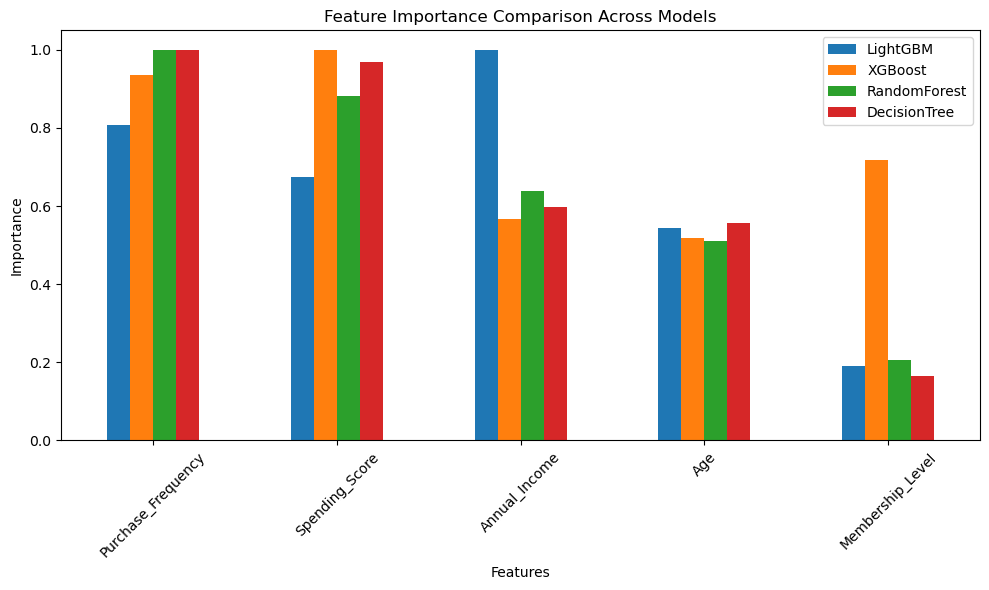

BEST MODEL: RandomForest (AUC: 0.712)


In [10]:
#feature importance prediction
imp_features = {}
imp_features['LightGBM'] = lgb_model.feature_importances_
imp_features['XGBoost'] = xgb_model.feature_importances_
imp_features['RandomForest'] = rf_model.feature_importances_
imp_features['DecisionTree'] = dt_model.feature_importances_
imp_features = pd.DataFrame(imp_features, index=x.columns)
imp_features = imp_features / imp_features.max()

comparison = {
    'LightGBM': lgb_auc, 'XGBoost': xgb_auc, 
    'RandomForest': rf_auc, 'DecisionTree': dt_auc,
}

#choosing the best model
best_model = max(comparison, key=comparison.get)
imp_features = imp_features.sort_values(by=best_model, ascending=False)
imp_features.plot(kind='bar', figsize=(10,6))
plt.title("Feature Importance Comparison Across Models")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


model_map = {
    'LightGBM': lgb_model,
    'XGBoost': xgb_model,
    'RandomForest': rf_model,
    'DecisionTree': dt_model
}
best_ml_model = model_map[best_model]
print(f"BEST MODEL: {best_model} (AUC: {comparison[best_model]:.3f})")

In [28]:
def business_rules(x_test):
    churn = np.zeros(len(x_test))
    # Low engagement then CHURN
    churn[(x_test['Spending_Score'] <= 3) & 
          (x_test['Purchase_Frequency'] <= 4)] = 1

    # High income but low spending then CHURN
    churn[(x_test['Annual_Income'] >= 60000) & 
          (x_test['Spending_Score'] <= 4)] = 1

    # Very low activity then CHURN
    churn[(x_test['Purchase_Frequency'] <= 2)] = 1

    # Loyal customers then STAY
    churn[(x_test['Spending_Score'] >= 8) & 
          (x_test['Purchase_Frequency'] >= 8)] = 0

    # Premium members then STAY
    churn[(x_test['Membership_Level'] >= 2) & 
          (x_test['Spending_Score'] >= 6)] = 0

    return churn

rule_preds = business_rules(x_test)

print("\nRule-Based Model Performance")
print("Accuracy:", round(accuracy_score(y_test, rule_preds), 3))
print("Precision:", round(precision_score(y_test, rule_preds, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, rule_preds, zero_division=0), 3))
print("F1 Score:", round(f1_score(y_test, rule_preds, zero_division=0), 3))


Rule-Based Model Performance
Accuracy: 0.667
Precision: 0.5
Recall: 0.105
F1 Score: 0.174


## Rule-Based Model Performance
The rule-based model was evaluated using standard classification metrics.
The model achieved a moderate accuracy of 66.7%, which may appear reasonable at first. However, accuracy alone is not a reliable indicator of performance in this case due to class imbalance.

The recall value is very low (0.105), indicating that the rule-based system was able to identify only a small portion of actual churned customers. This suggests that many churn cases were missed.
Although the precision is moderate (0.50), meaning that half of the predicted churn cases were correct, the overall effectiveness of the rule-based model is limited due to its inability to capture complex patterns in the data.

Overall, the rule-based approach provides interpretability and simple business insights, but its predictive performance is lower compared to machine learning models. This highlights the need for combining it with ML models in a hybrid approach.

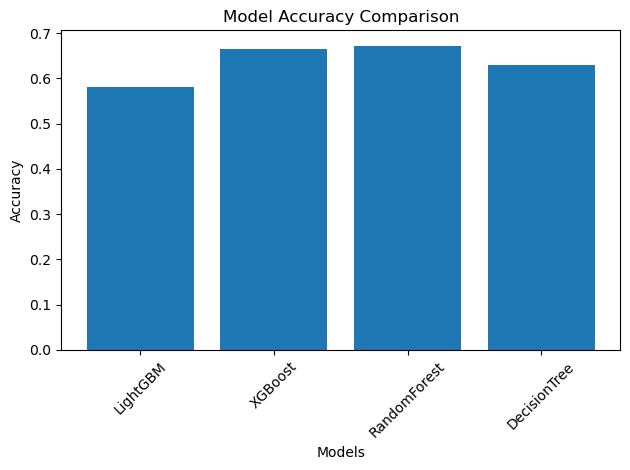

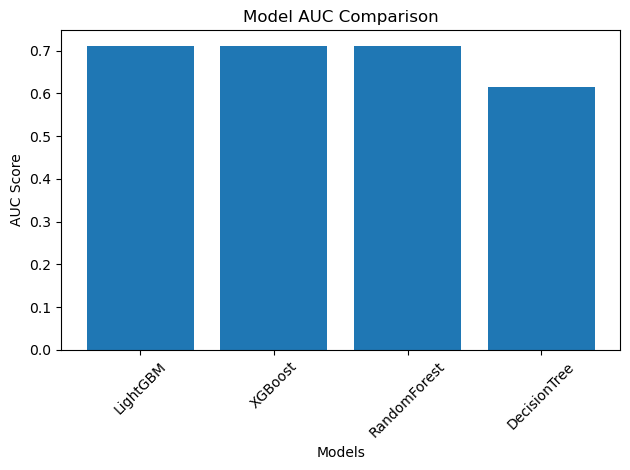

In [17]:
models = ['LightGBM', 'XGBoost', 'RandomForest', 'DecisionTree']

accuracy_scores = [
    accuracy_score(y_test, lgb_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, dt_pred)
]

auc_scores = [lgb_auc, xgb_auc, rf_auc, dt_auc]

# Accuracy Plot
plt.figure()
plt.bar(models, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# AUC Plot
plt.figure()
plt.bar(models, auc_scores)
plt.title("Model AUC Comparison")
plt.xlabel("Models")
plt.ylabel("AUC Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Hybrid Approach
A hybrid approach was implemented by combining rule-based logic with machine learning predictions.
- If both rule-based and ML model predict churn → High Risk
- If either one predicts churn → Medium Risk
- If both predict no churn → Low Risk

This classification helps in prioritizing customers for retention strategies and improves decision-making in real-world scenarios.


Sample Risk Predictions:
      Age  Annual_Income  Purchase_Frequency  Membership_Level  \
1851   61          64280                 9.7                 1   
588    58          68537                 5.5                 1   
853    44          27746                 6.9                 1   
1216   32          80145                 8.0                 3   
1706   67          77709                 3.8                 1   

      Spending_Score  Actual   Risk_Level  
1851              49       0     Low Risk  
588               53       1  Medium Risk  
853               62       0  Medium Risk  
1216              77       1     Low Risk  
1706              62       0     Low Risk  


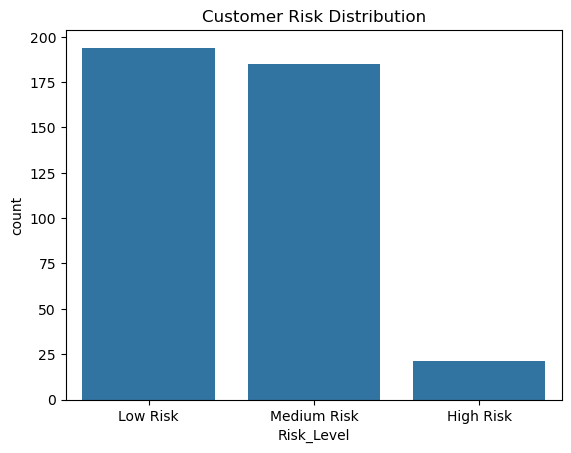

In [29]:
def hybrid_risk(x_test, ml_model):
    
    rule_preds = business_rules(x_test)
    ml_proba = ml_model.predict_proba(x_test)[:,1]
    ml_preds = (ml_proba > 0.4).astype(int)   # threshold
    risk = []

    for r, m in zip(rule_preds, ml_preds):
        if r == 1 and m == 1:
            risk.append("High Risk")
        elif r == 1 or m == 1:
            risk.append("Medium Risk")
        else:
            risk.append("Low Risk")
    return risk

risk_labels = hybrid_risk(x_test, best_ml_model)

res = x_test.copy()
res['Actual'] = y_test.values
res['Risk_Level'] = risk_labels

print("\nSample Risk Predictions:")
print(res.head())
sns.countplot(x=res['Risk_Level'])
plt.title("Customer Risk Distribution")
plt.show()

In [30]:
print("\nEnter Customer Details for Testing:")
age = int(input("Age: "))
income = float(input("Annual Income: "))
purchase_freq = int(input("Purchase Frequency: "))
print("Valid Membership Levels:", list(le.classes_))
membership = input("Membership Level: ")
spending = int(input("Spending Score (1-10): "))

try:
    membership_encoded = le.transform([membership])[0]
except:
    print("Invalid membership! Using default = Low")
    membership_encoded = 0

# Create dataframe
user_data = pd.DataFrame([{
    'Age': age,
    'Annual_Income': income,
    'Purchase_Frequency': purchase_freq,
    'Membership_Level': membership_encoded,
    'Spending_Score': spending
}])
ml_proba = best_ml_model.predict_proba(user_data)[:,1]
ml_pred = (ml_proba > 0.4).astype(int)[0]
rule_pred = business_rules(user_data)[0]

if rule_pred == 1 and ml_pred == 1:
    risk = "High Risk"
elif rule_pred == 1 or ml_pred == 1:
    risk = "Medium Risk"
else:
    risk = "Low Risk"
print("\n == Prediction Result ==")
print("ML Prediction:", ml_pred)
print("Rule-Based Prediction:", rule_pred)
print("Final Risk Level:", risk)


Enter Customer Details for Testing:


Age:  2
Annual Income:  22
Purchase Frequency:  2


Valid Membership Levels: ['Basic', 'Gold', 'Platinum', 'Silver']


Membership Level:  Basic
Spending Score (1-10):  1



 == Prediction Result ==
ML Prediction: 1
Rule-Based Prediction: 1.0
Final Risk Level: High Risk
